# 04 Correlation Bootstrapping

## Are calm-to-stress correlation changes larger than sampling uncertainty?

Notebook 03 measures the raw change

$$
\Delta \rho_{ij} = \hat{\rho}_{ij,\mathrm{stress}}
                  - \hat{\rho}_{ij,\mathrm{calm}}.
$$

This notebook adds inference. It uses the same Markov labels, balanced date window,
and three asset universes as the canonical correlation pipeline. The primary
outputs are moving-block bootstrap confidence intervals, approximate two-sided
bootstrap p-values, and Benjamini-Hochberg adjusted p-values for every asset pair.

The analysis is reproducible from the project database and writes its tables and
figures to `outputs/04_correlation_bootstrapping/`.

## Analysis map

1. Validate the project database and load labeled daily log returns.
2. Reproduce the balanced samples used by the raw-correlation pipeline.
3. Bootstrap calm and stress correlations for all pairs jointly.
4. Evaluate pair-level and universe-level average/median changes.
5. Correct pairwise inference for multiple testing.
6. Compare with the classical Fisher-z Gaussian approximation.
7. Check sensitivity to the moving-block length.
8. Export compact, reproducible results.

## 1. Setup

In [1]:
# =====================================================================
# Notebook 04 -- Correlation Bootstrapping: setup
#
# Adds inference to the raw correlation changes of notebook 03: moving-block
# bootstrap confidence intervals, two-sided bootstrap p-values, and BH-adjusted
# q-values per asset pair. Reads the labeled returns (read-only) and writes every
# report figure (PNG) and table (CSV) to outputs/04_correlation_bootstrapping/.
# =====================================================================
from __future__ import annotations

from pathlib import Path
import platform
import subprocess
import sys
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from IPython.display import display


def find_project_root(start: Path) -> Path:
    """Find the repository root when launched from the root or notebooks/."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import settings
from analysis.correlation_bootstrap import bootstrap_correlation_changes
from analysis.regime_correlations import (
    common_complete_case_dates,
    prepare_labeled_returns,
)
from features.regime_assignment import ETF_TABLE

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "04_correlation_bootstrapping"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

print(f"Database: {settings.DB_PATH}")
print(f"Outputs : {OUTPUT_DIR}")
print(
    f"Python {platform.python_version()} | duckdb={duckdb.__version__}, "
    f"pandas={pd.__version__}, numpy={np.__version__}, scipy={scipy.__version__}"
)

Database: C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\data\lsr.duckdb
Outputs : C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\04_correlation_bootstrapping
Python 3.12.10 | duckdb=1.5.3, pandas=2.3.3, numpy=2.3.4, scipy=1.16.3


## 2. Reproducibility settings

In [2]:
# Set this to True only when the database inputs need to be rebuilt.
RUN_UPSTREAM_PIPELINE = False

# Primary inference settings.
N_BOOTSTRAP = 2_000
BLOCK_LENGTH = 21
CONFIDENCE_LEVEL = 0.95
RANDOM_SEED = 20250624

# A lighter bootstrap is sufficient for the block-length robustness check.
SENSITIVITY_BOOTSTRAPS = 500
SENSITIVITY_BLOCK_LENGTHS = (5, 21, 63)

UPSTREAM_SCRIPTS = (
    "01_init_database.py",
    "02_fetch_market_prices.py",
    "04_build_regime_labels.py",
    "05_00_build_markov_switching_monthly.py",
    "06_assign_monthly_markov_regimes_to_daily_returns.py",
)

if RUN_UPSTREAM_PIPELINE:
    for script_name in UPSTREAM_SCRIPTS:
        script_path = PROJECT_ROOT / "scripts" / script_name
        print(f"Running {script_path.name} ...")
        subprocess.run([sys.executable, str(script_path)], cwd=PROJECT_ROOT, check=True)

print(
    f"Primary bootstrap: B={N_BOOTSTRAP:,}, block={BLOCK_LENGTH}, "
    f"confidence={CONFIDENCE_LEVEL:.0%}, seed={RANDOM_SEED}"
)

Primary bootstrap: B=2,000, block=21, confidence=95%, seed=20250624


## 3. Statistical design

### Why not an ordinary t-test?

For one pair we observe two correlations, not two independent samples *of*
correlations. Pearson correlation is bounded, its sampling distribution is not
generally Gaussian in raw correlation units, and daily returns are serially
dependent. A t-test on the list of asset-pair correlations would also treat
overlapping pairs such as SPY-EFA and SPY-EWG as independent, which they are not.

### Primary moving-block bootstrap

For each universe and bootstrap replicate:

1. Keep the balanced return panel in chronological order.
2. Draw circular blocks of 21 consecutive rows from the full panel, carrying
   each row's regime label with its returns.
3. Split every resampled panel into calm and stress observations, allowing the
   regime counts to vary naturally across replicates.
4. Recompute all pair correlations jointly from whole cross-sectional rows.
5. Store $\Delta\rho^*_{ij}=\rho^*_{ij,S}-\rho^*_{ij,C}$.

The 2.5% and 97.5% percentiles form a 95% interval. The approximate two-sided
bootstrap p-value compares the centered bootstrap errors with the magnitude of
the observed change under a zero null. Since
many pairs are tested, Benjamini-Hochberg q-values control the false discovery
rate within each universe.

The universe-level average and median are recomputed inside every replicate.
This preserves dependence among pair correlations and directly addresses
whether the *typical* correlation changed.

### Gaussian benchmark

The Fisher transformation, $z=\operatorname{atanh}(r)$, supplies a classical
normal approximation for the difference between two independent correlations.
It is reported as a benchmark, not as the primary result, because it assumes
i.i.d. bivariate-normal observations and ignores return autocorrelation.

## 4. Database checks and labeled returns

In [3]:
settings.require_data_dir()
if not settings.DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found: {settings.DB_PATH}. "
        "Run the upstream scripts or set RUN_UPSTREAM_PIPELINE=True."
    )

con = duckdb.connect(str(settings.DB_PATH), read_only=True)
available_tables = set(con.execute("SHOW TABLES").fetchdf()["name"])
if ETF_TABLE not in available_tables:
    raise RuntimeError(
        f"Missing {ETF_TABLE}. Run scripts/06_assign_monthly_markov_regimes_to_daily_returns.py."
    )

table_description = con.execute(f"DESCRIBE {ETF_TABLE}").fetchdf()
required_columns = {"date", "ms_stress", *settings.ETF_ASSETS}
missing_columns = required_columns - set(table_description["column_name"])
if missing_columns:
    raise RuntimeError(f"Labeled table is missing: {', '.join(sorted(missing_columns))}")

display(table_description)

,column_name,column_type,null,key,default,extra
0,date,DATE,NO,PRI,None,None
1,AGG,DOUBLE,YES,None,None,None
2,DBC,DOUBLE,YES,None,None,None
3,EEM,DOUBLE,YES,None,None,None
4,EFA,DOUBLE,YES,None,None,None
5,EWG,DOUBLE,YES,None,None,None
6,EWJ,DOUBLE,YES,None,None,None
7,EWU,DOUBLE,YES,None,None,None
8,GLD,DOUBLE,YES,None,None,None
9,HYG,DOUBLE,YES,None,None,None


In [4]:
raw_labeled = con.execute(f"SELECT * FROM {ETF_TABLE} ORDER BY date").fetchdf()
raw_labeled["date"] = pd.to_datetime(raw_labeled["date"])

common_dates = common_complete_case_dates(raw_labeled, list(settings.ETF_ASSETS))
balanced_raw = raw_labeled[raw_labeled["date"].isin(common_dates)].copy()

data_audit = pd.DataFrame(
    [
        {
            "source_table": ETF_TABLE,
            "raw_rows": len(raw_labeled),
            "balanced_rows": len(balanced_raw),
            "balanced_start": balanced_raw["date"].min().date(),
            "balanced_end": balanced_raw["date"].max().date(),
            "calm_days": int((balanced_raw["ms_stress"] == 0).sum()),
            "stress_days": int((balanced_raw["ms_stress"] == 1).sum()),
            "stress_share": float(balanced_raw["ms_stress"].mean()),
        }
    ]
)
display(data_audit)

,source_table,raw_rows,balanced_rows,balanced_start,balanced_end,calm_days,stress_days,stress_share
0,etf_returns_monthly_markov_labeled,6518,4711,2007-04-12,2025-12-30,2443,2268,0.481426


## 5. Correlation universes

The notebook deliberately imports ticker lists from `src/settings/tickers.py`.
Panel A is the cross-asset basket, Panel B is international equity, and
`etf_assets` is their union. All three are restricted to the union's common
complete-case dates, matching scripts 07-09.

In [5]:
UNIVERSES = {
    "panel_a_cross_asset": list(settings.PANEL_A),
    "panel_b_international_equity": list(settings.PANEL_B),
    "etf_assets": list(settings.ETF_ASSETS),
}

universe_data = {}
sample_rows = []
for universe, columns in UNIVERSES.items():
    prepared = prepare_labeled_returns(
        raw_labeled,
        columns,
        restrict_dates=common_dates,
    )
    universe_data[universe] = prepared
    sample_rows.append(
        {
            "universe": universe,
            "n_assets": len(columns),
            "n_pairs": len(columns) * (len(columns) - 1) // 2,
            "n_days": len(prepared),
            "n_calm_days": int((prepared["ms_stress"] == 0).sum()),
            "n_stress_days": int((prepared["ms_stress"] == 1).sum()),
            "start_date": prepared["date"].min().date(),
            "end_date": prepared["date"].max().date(),
        }
    )

sample_summary = pd.DataFrame(sample_rows)
display(sample_summary)

,universe,n_assets,n_pairs,n_days,n_calm_days,n_stress_days,start_date,end_date
0,panel_a_cross_asset,9,36,4711,2443,2268,2007-04-12,2025-12-30
1,panel_b_international_equity,6,15,4711,2443,2268,2007-04-12,2025-12-30
2,etf_assets,14,91,4711,2443,2268,2007-04-12,2025-12-30


## 6. Primary moving-block bootstrap

In [6]:
seed_sequences = np.random.SeedSequence(RANDOM_SEED).spawn(len(UNIVERSES))
bootstrap_results = {}

started = time.perf_counter()
for (universe, columns), seed_sequence in zip(UNIVERSES.items(), seed_sequences):
    universe_seed = int(seed_sequence.generate_state(1)[0])
    print(f"Bootstrapping {universe} ({len(columns)} assets) ...")
    bootstrap_results[universe] = bootstrap_correlation_changes(
        universe_data[universe],
        columns,
        universe=universe,
        n_bootstrap=N_BOOTSTRAP,
        block_length=BLOCK_LENGTH,
        confidence_level=CONFIDENCE_LEVEL,
        seed=universe_seed,
    )

elapsed = time.perf_counter() - started
print(f"Completed {len(bootstrap_results)} universes in {elapsed:.1f} seconds.")

Bootstrapping panel_a_cross_asset (9 assets) ...


Bootstrapping panel_b_international_equity (6 assets) ...


Bootstrapping etf_assets (14 assets) ...


Completed 3 universes in 6.6 seconds.


In [7]:
universe_summary = pd.concat(
    [result.universe_summary for result in bootstrap_results.values()],
    ignore_index=True,
)
pair_results = pd.concat(
    [result.pair_results for result in bootstrap_results.values()],
    ignore_index=True,
)

summary_columns = [
    "universe",
    "n_assets",
    "n_pairs",
    "n_calm_days",
    "n_stress_days",
    "bootstrap_calm_days_min",
    "bootstrap_calm_days_max",
    "bootstrap_stress_days_min",
    "bootstrap_stress_days_max",
    "avg_delta_corr",
    "avg_ci_low",
    "avg_ci_high",
    "avg_p_boot_two_sided",
    "median_delta_corr",
    "median_ci_low",
    "median_ci_high",
    "median_p_boot_two_sided",
    "significant_increases_95",
    "significant_decreases_95",
    "significant_pairs_fdr_05",
]
display(universe_summary[summary_columns].round(4))

,universe,n_assets,n_pairs,n_calm_days,n_stress_days,bootstrap_calm_days_min,bootstrap_calm_days_max,bootstrap_stress_days_min,bootstrap_stress_days_max,avg_delta_corr,avg_ci_low,avg_ci_high,avg_p_boot_two_sided,median_delta_corr,median_ci_low,median_ci_high,median_p_boot_two_sided,significant_increases_95,significant_decreases_95,significant_pairs_fdr_05
0,panel_a_cross_asset,9,36,2443,2268,1918,2960,1751,2793,-0.0246,-0.0657,0.0192,0.2674,-0.0243,-0.0596,0.0199,0.2174,6,8,11
1,panel_b_international_equity,6,15,2443,2268,1883,2963,1748,2828,0.1245,0.0835,0.1571,0.0005,0.1247,0.0817,0.1620,0.0005,15,0,15
2,etf_assets,14,91,2443,2268,1922,2977,1734,2789,0.0291,-0.0118,0.0682,0.1584,0.0499,-0.0050,0.1004,0.0630,35,16,50


## 7. Universe-level average and median effects

Each point below is the observed average pairwise change. Its interval comes
from averaging all pair changes within each bootstrap replicate, so shared
assets and cross-pair dependence are retained.

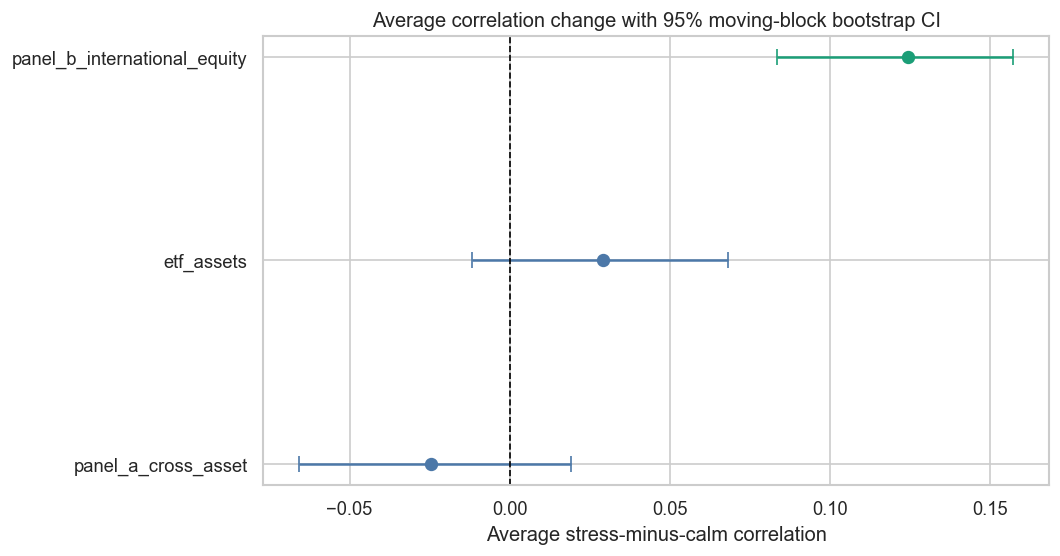

In [8]:
plot_summary = universe_summary.sort_values("avg_delta_corr").reset_index(drop=True)
y = np.arange(len(plot_summary))
x = plot_summary["avg_delta_corr"].to_numpy()
xerr = np.vstack(
    [
        x - plot_summary["avg_ci_low"].to_numpy(),
        plot_summary["avg_ci_high"].to_numpy() - x,
    ]
)

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [
    "#1b9e77" if low > 0 else "#d95f02" if high < 0 else "#4c78a8"
    for low, high in zip(plot_summary["avg_ci_low"], plot_summary["avg_ci_high"])
]
for index, color in enumerate(colors):
    ax.errorbar(
        x[index],
        y[index],
        xerr=xerr[:, index : index + 1],
        fmt="o",
        color=color,
        capsize=5,
        markersize=7,
    )
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(y, plot_summary["universe"])
ax.set_xlabel("Average stress-minus-calm correlation")
ax.set_ylabel("")
ax.set_title("Average correlation change with 95% moving-block bootstrap CI")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "universe_average_delta_ci.png", bbox_inches="tight")
plt.show()

## 8. Pair-level inference

A pair is directionally supported at 95% when its interval excludes zero.
`q_value_bh < 0.05` is the stricter decision after controlling the expected
false discovery rate across all pairs in the same universe.

In [9]:
pair_display_columns = [
    "universe",
    "asset_i",
    "asset_j",
    "corr_calm",
    "corr_stress",
    "delta_corr",
    "ci_low",
    "ci_high",
    "p_boot_two_sided",
    "q_value_bh",
    "direction",
]

for universe in UNIVERSES:
    print(f"\n{universe}: largest increases")
    display(
        pair_results.query("universe == @universe")
        .nlargest(8, "delta_corr")[pair_display_columns]
        .round(4)
    )
    print(f"{universe}: largest decreases")
    display(
        pair_results.query("universe == @universe")
        .nsmallest(8, "delta_corr")[pair_display_columns]
        .round(4)
    )


panel_a_cross_asset: largest increases


,universe,asset_i,asset_j,corr_calm,corr_stress,delta_corr,ci_low,ci_high,p_boot_two_sided,q_value_bh,direction
34,panel_a_cross_asset,DBC,VNQ,0.1081,0.3408,0.2327,0.1276,0.3323,0.0005,0.0026,increase
35,panel_a_cross_asset,USO,VNQ,0.0671,0.2984,0.2313,0.1188,0.3406,0.0005,0.0026,increase
7,panel_a_cross_asset,SPY,VNQ,0.5850,0.7948,0.2098,0.1473,0.2755,0.0005,0.0026,increase
5,panel_a_cross_asset,SPY,DBC,0.2939,0.4679,0.1740,0.0776,0.2721,0.0005,0.0026,increase
6,panel_a_cross_asset,SPY,USO,0.2467,0.4187,0.1720,0.0586,0.2844,0.0035,0.0140,increase
23,panel_a_cross_asset,AGG,DBC,-0.1001,-0.0015,0.0986,-0.0089,0.1930,0.0530,0.1271,inconclusive
24,panel_a_cross_asset,AGG,USO,-0.1316,-0.0333,0.0983,-0.0189,0.1982,0.0785,0.1662,inconclusive
27,panel_a_cross_asset,HYG,DBC,0.2972,0.3936,0.0964,0.0017,0.1899,0.0445,0.1144,increase


panel_a_cross_asset: largest decreases


,universe,asset_i,asset_j,corr_calm,corr_stress,delta_corr,ci_low,ci_high,p_boot_two_sided,q_value_bh,direction
20,panel_a_cross_asset,TLT,VNQ,0.1226,-0.2518,-0.3744,-0.4716,-0.2668,0.0005,0.0026,decrease
14,panel_a_cross_asset,SHY,VNQ,0.1079,-0.1976,-0.3055,-0.4326,-0.1769,0.0005,0.0026,decrease
25,panel_a_cross_asset,AGG,VNQ,0.2403,-0.0366,-0.2769,-0.3883,-0.1510,0.0005,0.0026,decrease
15,panel_a_cross_asset,TLT,AGG,0.8770,0.6472,-0.2298,-0.3590,-0.0900,0.0010,0.0045,decrease
9,panel_a_cross_asset,SHY,AGG,0.7522,0.5379,-0.2142,-0.3703,-0.0425,0.0060,0.0213,decrease
16,panel_a_cross_asset,TLT,HYG,-0.0034,-0.1797,-0.1763,-0.2964,-0.0519,0.0065,0.0213,decrease
1,panel_a_cross_asset,SPY,TLT,-0.2208,-0.3581,-0.1374,-0.2503,-0.0192,0.0215,0.0645,decrease
10,panel_a_cross_asset,SHY,HYG,0.0358,-0.0846,-0.1204,-0.2580,0.0343,0.1009,0.1913,inconclusive



panel_b_international_equity: largest increases


...

,universe,asset_i,asset_j,corr_calm,corr_stress,delta_corr,ci_low,ci_high,p_boot_two_sided,q_value_bh,direction
42,panel_b_international_equity,EFA,EWG,0.9119,0.9494,0.0375,0.0223,0.0536,0.0005,0.0005,increase
43,panel_b_international_equity,EFA,EWU,0.9079,0.9484,0.0405,0.0212,0.0575,0.0005,0.0005,increase
48,panel_b_international_equity,EWG,EWU,0.8119,0.8958,0.0839,0.0485,0.1175,0.0005,0.0005,increase
36,panel_b_international_equity,SPY,EFA,0.8102,0.9090,0.0988,0.0615,0.1310,0.0005,0.0005,increase
41,panel_b_international_equity,EFA,EEM,0.7990,0.9004,0.1014,0.0677,0.1323,0.0005,0.0005,increase
44,panel_b_international_equity,EFA,EWJ,0.7854,0.8892,0.1038,0.0621,0.1400,0.0005,0.0005,increase
37,panel_b_international_equity,SPY,EEM,0.7312,0.8542,0.1230,0.0762,0.1685,0.0005,0.0005,increase
38,panel_b_international_equity,SPY,EWG,0.7303,0.8550,0.1247,0.0775,0.1673,0.0005,0.0005,increase



etf_assets: largest increases


,universe,asset_i,asset_j,corr_calm,corr_stress,delta_corr,ci_low,ci_high,p_boot_two_sided,q_value_bh,direction
130,etf_assets,VNQ,EWU,0.4791,0.7136,0.2345,0.1504,0.3152,0.0005,0.0016,increase
115,etf_assets,DBC,VNQ,0.1081,0.3408,0.2327,0.1240,0.3291,0.0005,0.0016,increase
121,etf_assets,USO,VNQ,0.0671,0.2984,0.2313,0.1105,0.3429,0.0005,0.0016,increase
128,etf_assets,VNQ,EEM,0.4870,0.7150,0.2280,0.1527,0.3004,0.0005,0.0016,increase
129,etf_assets,VNQ,EWG,0.4636,0.6857,0.2220,0.1390,0.2985,0.0005,0.0016,increase
131,etf_assets,VNQ,EWJ,0.4204,0.6417,0.2213,0.1394,0.2936,0.0005,0.0016,increase
127,etf_assets,VNQ,EFA,0.5265,0.7365,0.2101,0.1381,0.2806,0.0005,0.0016,increase
58,etf_assets,SPY,VNQ,0.5850,0.7948,0.2098,0.1479,0.2752,0.0005,0.0016,increase


etf_assets: largest decreases


,universe,asset_i,asset_j,corr_calm,corr_stress,delta_corr,ci_low,ci_high,p_boot_two_sided,q_value_bh,direction
81,etf_assets,TLT,VNQ,0.1226,-0.2518,-0.3744,-0.4748,-0.2673,0.0005,0.0016,decrease
70,etf_assets,SHY,VNQ,0.1079,-0.1976,-0.3055,-0.4315,-0.1788,0.0005,0.0016,decrease
91,etf_assets,AGG,VNQ,0.2403,-0.0366,-0.2769,-0.3953,-0.1472,0.0005,0.0016,decrease
76,etf_assets,TLT,AGG,0.8770,0.6472,-0.2298,-0.3580,-0.0903,0.0005,0.0016,decrease
65,etf_assets,SHY,AGG,0.7522,0.5379,-0.2142,-0.3698,-0.0449,0.0045,0.0100,decrease
83,etf_assets,TLT,EEM,-0.1419,-0.3411,-0.1991,-0.2999,-0.1006,0.0005,0.0016,decrease
77,etf_assets,TLT,HYG,-0.0034,-0.1797,-0.1763,-0.2994,-0.0503,0.0085,0.0176,decrease
72,etf_assets,SHY,EEM,-0.1046,-0.2770,-0.1724,-0.3009,-0.0424,0.0075,0.0159,decrease


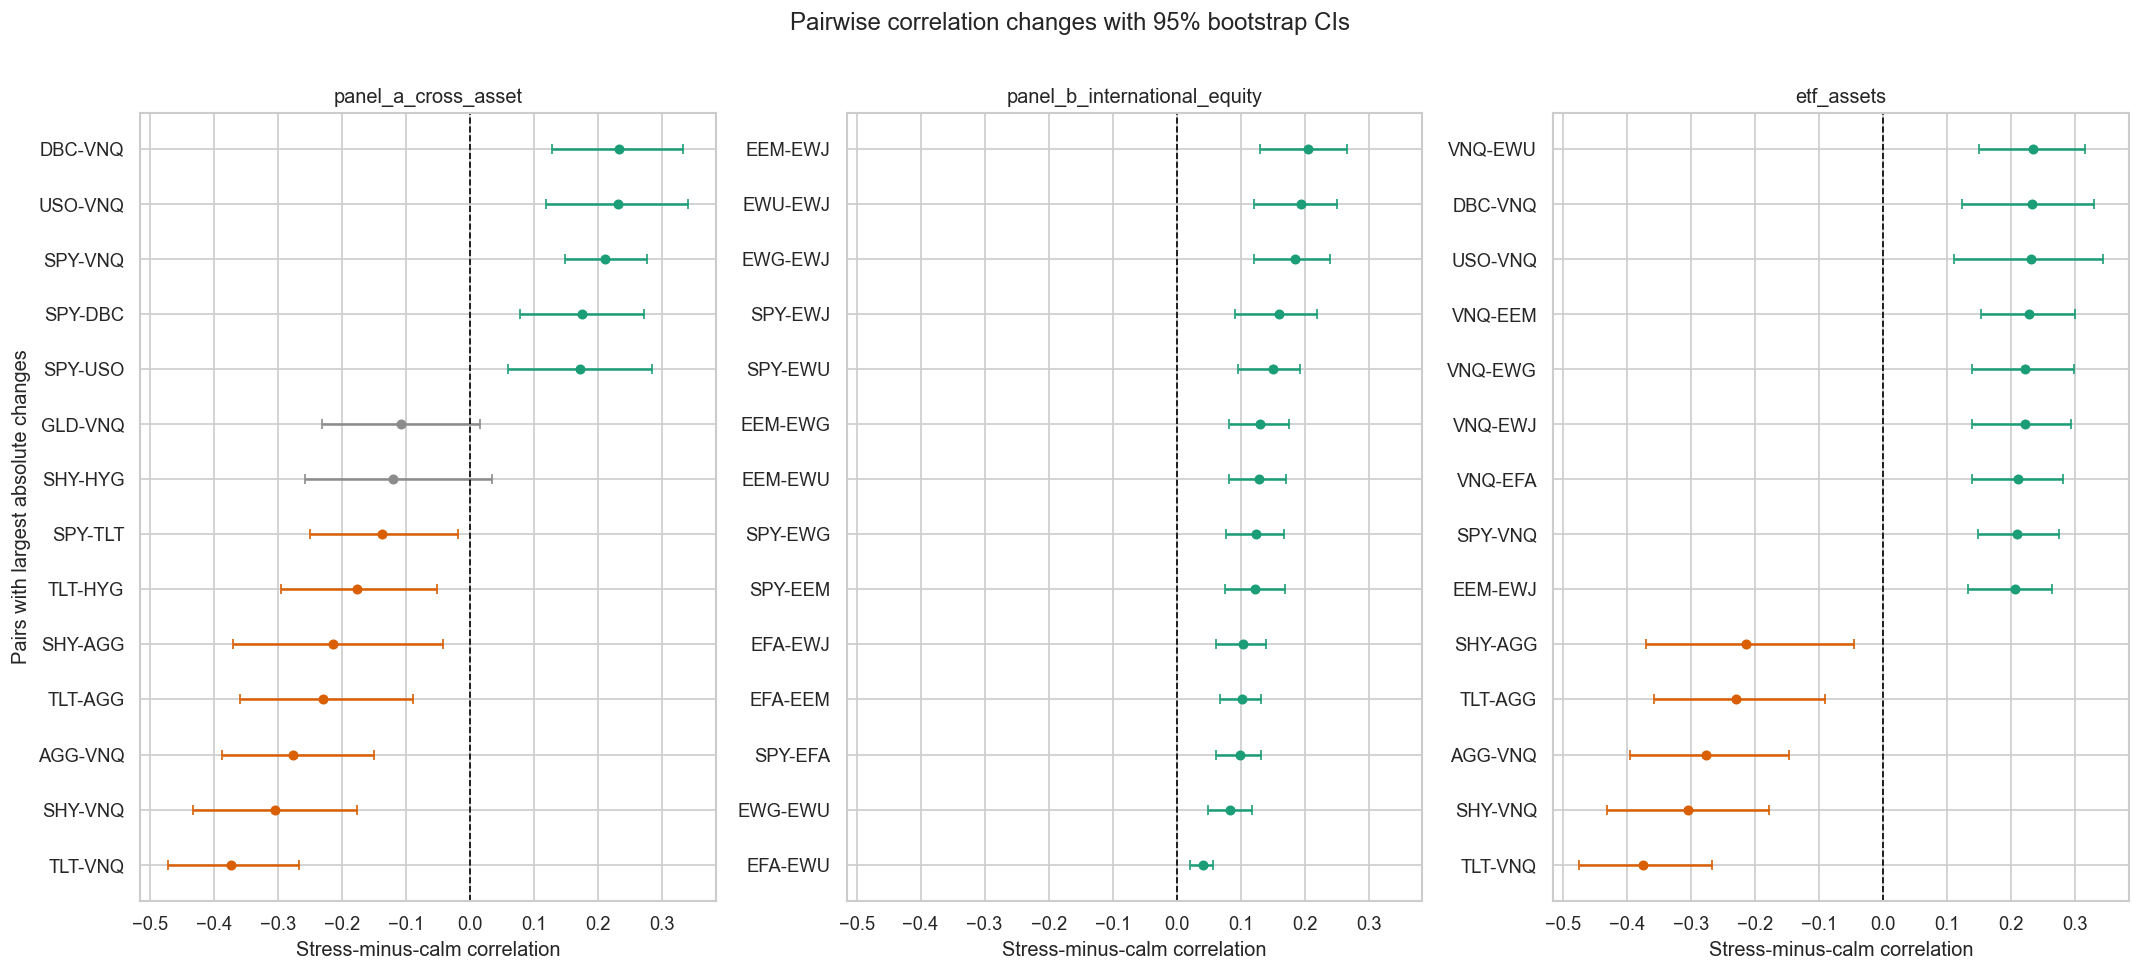

In [10]:
fig, axes = plt.subplots(1, len(UNIVERSES), figsize=(18, 8), sharex=True)

for ax, universe in zip(axes, UNIVERSES):
    subset = pair_results.query("universe == @universe").copy()
    subset["abs_delta"] = subset["delta_corr"].abs()
    subset = subset.nlargest(14, "abs_delta").sort_values("delta_corr")
    subset["pair"] = subset["asset_i"] + "-" + subset["asset_j"]
    y = np.arange(len(subset))
    x = subset["delta_corr"].to_numpy()
    xerr = np.vstack(
        [
            x - subset["ci_low"].to_numpy(),
            subset["ci_high"].to_numpy() - x,
        ]
    )
    colors = subset["direction"].map(
        {"increase": "#1b9e77", "decrease": "#d95f02", "inconclusive": "#8c8c8c"}
    )
    for index, color in enumerate(colors):
        ax.errorbar(
            x[index],
            y[index],
            xerr=xerr[:, index : index + 1],
            fmt="o",
            color=color,
            capsize=3,
            markersize=5,
        )
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_yticks(y, subset["pair"])
    ax.set_title(universe)
    ax.set_xlabel("Stress-minus-calm correlation")

axes[0].set_ylabel("Pairs with largest absolute changes")
fig.suptitle("Pairwise correlation changes with 95% bootstrap CIs", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pairwise_delta_ci.png", bbox_inches="tight")
plt.show()

In [11]:
decision_counts = (
    pair_results.groupby(["universe", "direction"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["increase", "decrease", "inconclusive"], fill_value=0)
)
decision_counts["fdr_significant"] = pair_results.groupby("universe")[
    "significant_fdr_05"
].sum()
decision_counts["total_pairs"] = pair_results.groupby("universe").size()
decision_counts["fdr_significant_share"] = (
    decision_counts["fdr_significant"] / decision_counts["total_pairs"]
)
display(decision_counts.reset_index().round(4))

direction,universe,increase,decrease,inconclusive,fdr_significant,total_pairs,fdr_significant_share
0,etf_assets,35,16,40,50,91,0.5495
1,panel_a_cross_asset,6,8,22,11,36,0.3056
2,panel_b_international_equity,15,0,0,15,15,1.0000


## 9. Bootstrap distributions

The histogram is the sampling distribution of the universe-level average
$\Delta\rho$. Zero is the no-change value. A distribution concentrated on one
side of zero gives a small bootstrap-tail p-value; broad overlap with zero gives
the high p-value anticipated when the effect is small relative to uncertainty.

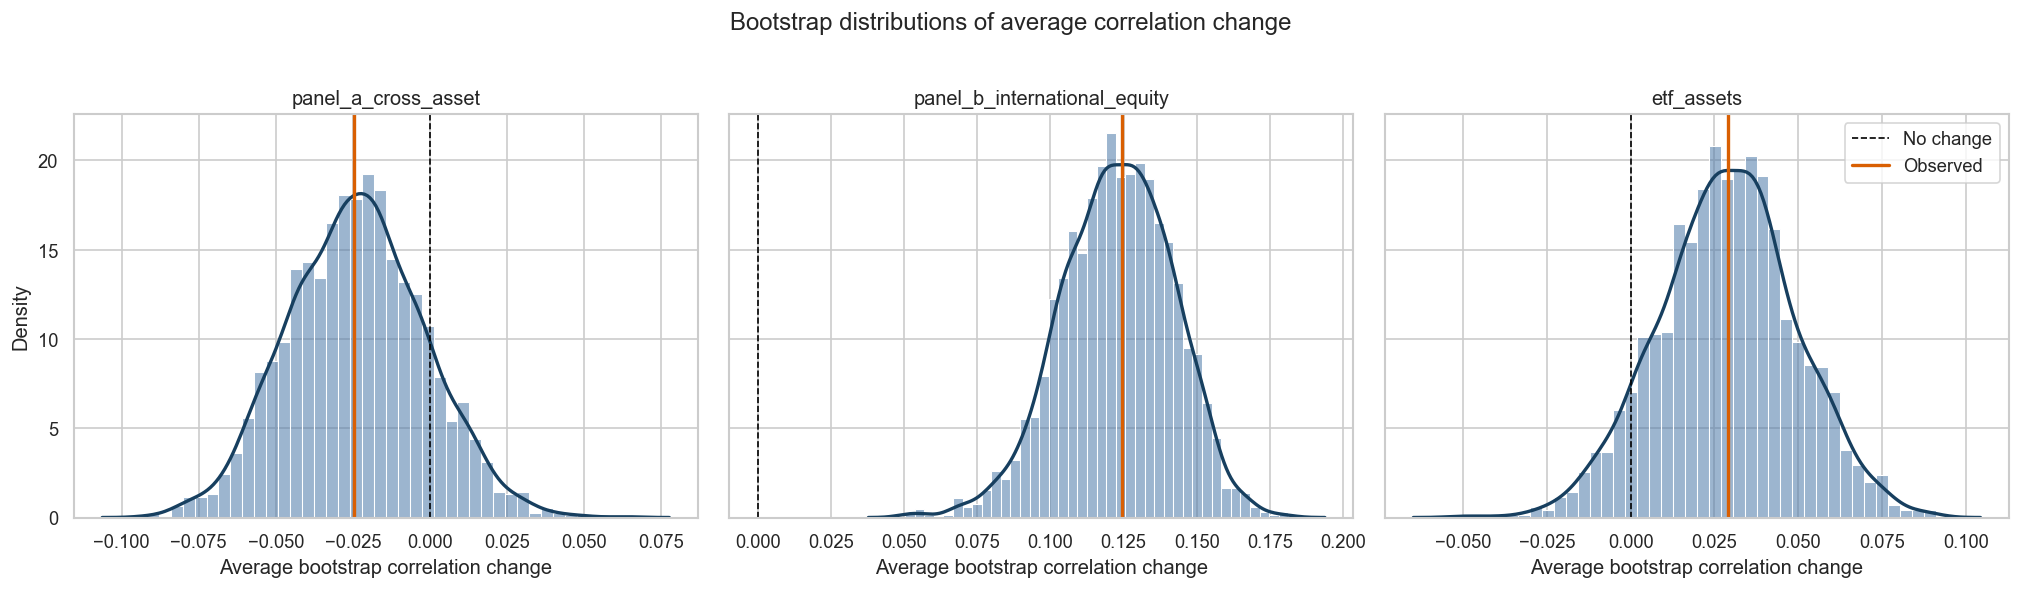

In [12]:
fig, axes = plt.subplots(1, len(UNIVERSES), figsize=(17, 4.8), sharey=True)

for ax, universe in zip(axes, UNIVERSES):
    draws = bootstrap_results[universe].delta_draws.mean(axis=1)
    observed = universe_summary.loc[
        universe_summary["universe"] == universe, "avg_delta_corr"
    ].iloc[0]
    sns.histplot(draws, bins=40, stat="density", color="#4c78a8", alpha=0.55, ax=ax)
    sns.kdeplot(draws, color="#173f5f", linewidth=2, ax=ax)
    ax.axvline(0, color="black", linewidth=1, linestyle="--", label="No change")
    ax.axvline(observed, color="#d95f02", linewidth=2, label="Observed")
    ax.set_title(universe)
    ax.set_xlabel("Average bootstrap correlation change")

axes[0].set_ylabel("Density")
axes[-1].legend(frameon=True)
fig.suptitle("Bootstrap distributions of average correlation change", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bootstrap_average_delta_distributions.png", bbox_inches="tight")
plt.show()

## 10. Moving-block bootstrap versus Fisher-z

This comparison answers the intuitive "two Gaussians" idea directly. Fisher-z
normalizes each correlation and tests their difference using a normal reference
distribution. If Fisher-z finds substantially more significance, the difference
usually reflects its stronger i.i.d. assumptions rather than extra information.

,universe,n_pairs,bootstrap_fdr_significant,fisher_unadjusted_significant,both,bootstrap_only,fisher_only,neither
0,etf_assets,91,50,73,50,0,23,18
1,panel_a_cross_asset,36,11,25,11,0,14,11
2,panel_b_international_equity,15,15,15,15,0,0,0


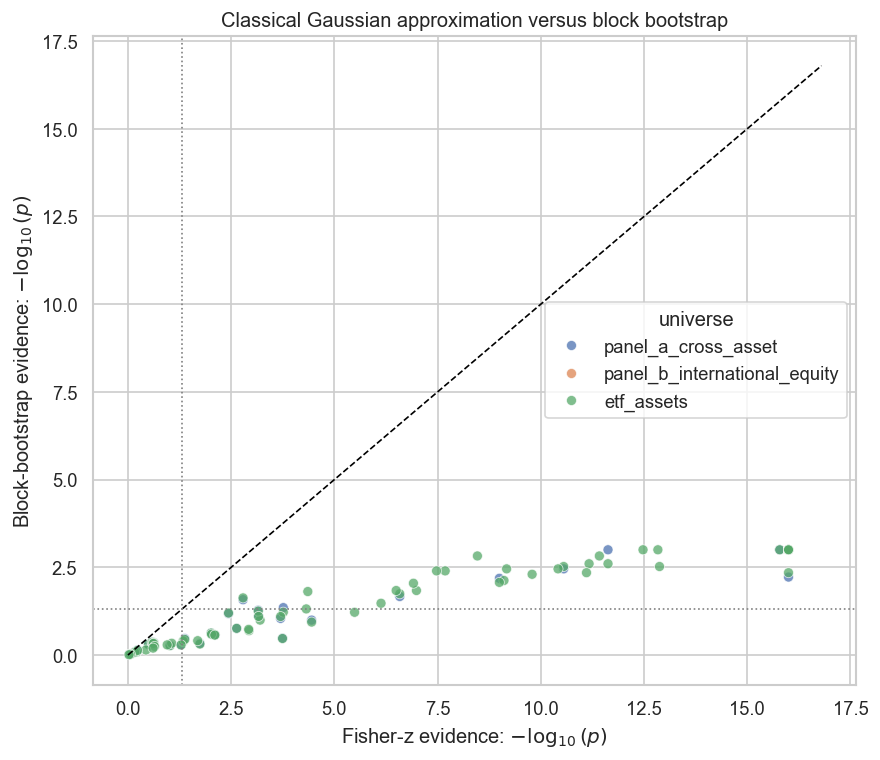

In [13]:
comparison_rows = []
for universe, subset in pair_results.groupby("universe"):
    bootstrap_sig = subset["q_value_bh"] < 0.05
    fisher_sig = subset["p_fisher_z"] < 0.05
    comparison_rows.append(
        {
            "universe": universe,
            "n_pairs": len(subset),
            "bootstrap_fdr_significant": int(bootstrap_sig.sum()),
            "fisher_unadjusted_significant": int(fisher_sig.sum()),
            "both": int((bootstrap_sig & fisher_sig).sum()),
            "bootstrap_only": int((bootstrap_sig & ~fisher_sig).sum()),
            "fisher_only": int((~bootstrap_sig & fisher_sig).sum()),
            "neither": int((~bootstrap_sig & ~fisher_sig).sum()),
        }
    )

method_comparison = pd.DataFrame(comparison_rows)
display(method_comparison)

plot_pairs = pair_results.copy()
minimum_p = 2 / (N_BOOTSTRAP + 1)
plot_pairs["bootstrap_evidence"] = -np.log10(
    plot_pairs["p_boot_two_sided"].clip(lower=minimum_p)
)
plot_pairs["fisher_evidence"] = -np.log10(plot_pairs["p_fisher_z"].clip(lower=1e-16))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.scatterplot(
    data=plot_pairs,
    x="fisher_evidence",
    y="bootstrap_evidence",
    hue="universe",
    alpha=0.75,
    ax=ax,
)
limit = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, limit], [0, limit], color="black", linestyle="--", linewidth=1)
threshold = -np.log10(0.05)
ax.axhline(threshold, color="grey", linestyle=":", linewidth=1)
ax.axvline(threshold, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel(r"Fisher-z evidence: $-\log_{10}(p)$")
ax.set_ylabel(r"Block-bootstrap evidence: $-\log_{10}(p)$")
ax.set_title("Classical Gaussian approximation versus block bootstrap")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bootstrap_vs_fisher.png", bbox_inches="tight")
plt.show()

## 11. Block-length sensitivity

Five observations allow relatively weak dependence, 21 approximates one
trading month, and 63 approximates one quarter. The point estimate is unchanged;
only the resampling-based uncertainty should move. Stable conclusions should
not depend on a single reasonable block length.

,universe,block_length,sensitivity_draws,avg_delta_corr,avg_ci_low,avg_ci_high,avg_p_boot_two_sided
2,etf_assets,5,500,0.0291,-0.0063,0.0599,0.0858
5,etf_assets,21,2000,0.0291,-0.0118,0.0682,0.1584
8,etf_assets,63,500,0.0291,-0.0130,0.0712,0.2136
0,panel_a_cross_asset,5,500,-0.0246,-0.0564,0.0098,0.1637
3,panel_a_cross_asset,21,2000,-0.0246,-0.0657,0.0192,0.2674
6,panel_a_cross_asset,63,500,-0.0246,-0.0738,0.0312,0.3633
1,panel_b_international_equity,5,500,0.1245,0.0947,0.1516,0.0020
4,panel_b_international_equity,21,2000,0.1245,0.0835,0.1571,0.0005
7,panel_b_international_equity,63,500,0.1245,0.0692,0.1597,0.0020


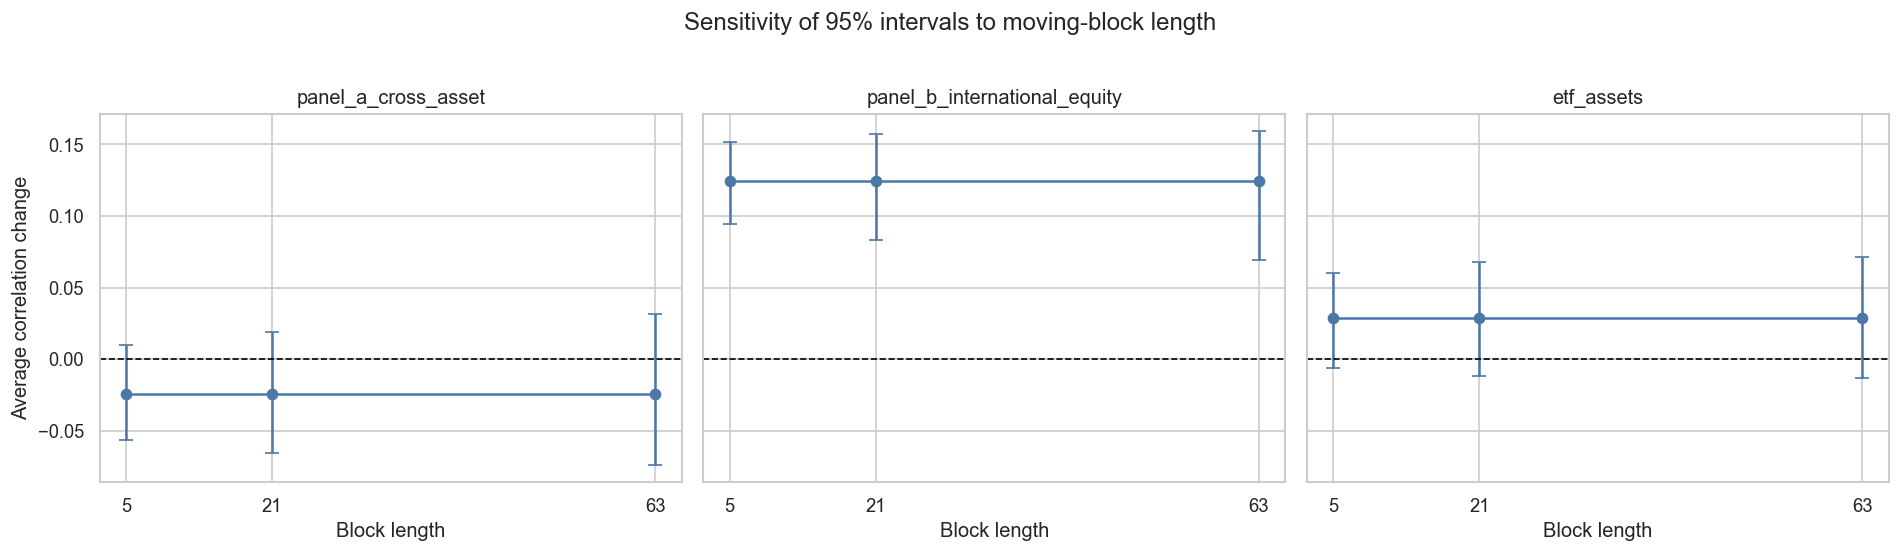

In [14]:
sensitivity_frames = []

for block_length in SENSITIVITY_BLOCK_LENGTHS:
    if block_length == BLOCK_LENGTH:
        primary = universe_summary.copy()
        primary["sensitivity_draws"] = N_BOOTSTRAP
        sensitivity_frames.append(primary)
        continue

    block_seeds = np.random.SeedSequence(
        RANDOM_SEED + block_length
    ).spawn(len(UNIVERSES))
    for (universe, columns), seed_sequence in zip(UNIVERSES.items(), block_seeds):
        universe_seed = int(seed_sequence.generate_state(1)[0])
        result = bootstrap_correlation_changes(
            universe_data[universe],
            columns,
            universe=universe,
            n_bootstrap=SENSITIVITY_BOOTSTRAPS,
            block_length=block_length,
            confidence_level=CONFIDENCE_LEVEL,
            seed=universe_seed,
        )
        frame = result.universe_summary.copy()
        frame["sensitivity_draws"] = SENSITIVITY_BOOTSTRAPS
        sensitivity_frames.append(frame)

block_sensitivity = pd.concat(sensitivity_frames, ignore_index=True)
sensitivity_columns = [
    "universe",
    "block_length",
    "sensitivity_draws",
    "avg_delta_corr",
    "avg_ci_low",
    "avg_ci_high",
    "avg_p_boot_two_sided",
]
display(
    block_sensitivity[sensitivity_columns]
    .sort_values(["universe", "block_length"])
    .round(4)
)

fig, axes = plt.subplots(1, len(UNIVERSES), figsize=(16, 4.5), sharey=True)
for ax, universe in zip(axes, UNIVERSES):
    subset = (
        block_sensitivity.query("universe == @universe")
        .sort_values("block_length")
        .reset_index(drop=True)
    )
    x = subset["block_length"].to_numpy()
    y = subset["avg_delta_corr"].to_numpy()
    yerr = np.vstack(
        [
            y - subset["avg_ci_low"].to_numpy(),
            subset["avg_ci_high"].to_numpy() - y,
        ]
    )
    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=4, color="#4c78a8")
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xticks(x)
    ax.set_xlabel("Block length")
    ax.set_title(universe)

axes[0].set_ylabel("Average correlation change")
fig.suptitle("Sensitivity of 95% intervals to moving-block length", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "block_length_sensitivity.png", bbox_inches="tight")
plt.show()

## 12. Evidence-based interpretation

In [15]:
def average_evidence(row: pd.Series) -> str:
    if row["avg_ci_low"] > 0:
        return "Average correlation increased in stress"
    if row["avg_ci_high"] < 0:
        return "Average correlation decreased in stress"
    return "Average change is not distinguishable from zero"


interpretation = universe_summary.copy()
interpretation["average_evidence"] = interpretation.apply(average_evidence, axis=1)
interpretation["fdr_significant_share"] = (
    interpretation["significant_pairs_fdr_05"] / interpretation["n_pairs"]
)
interpretation = interpretation[
    [
        "universe",
        "avg_delta_corr",
        "avg_ci_low",
        "avg_ci_high",
        "avg_p_boot_two_sided",
        "median_delta_corr",
        "median_ci_low",
        "median_ci_high",
        "significant_increases_95",
        "significant_decreases_95",
        "significant_pairs_fdr_05",
        "fdr_significant_share",
        "average_evidence",
    ]
]
display(interpretation.round(4))

for row in interpretation.itertuples(index=False):
    print(
        f"{row.universe}: {row.average_evidence.lower()} "
        f"(average delta={row.avg_delta_corr:+.3f}, "
        f"95% CI [{row.avg_ci_low:+.3f}, {row.avg_ci_high:+.3f}], "
        f"bootstrap p={row.avg_p_boot_two_sided:.4f}). "
        f"{row.significant_pairs_fdr_05} pairs remain significant after BH correction."
    )

,universe,avg_delta_corr,avg_ci_low,avg_ci_high,avg_p_boot_two_sided,median_delta_corr,median_ci_low,median_ci_high,significant_increases_95,significant_decreases_95,significant_pairs_fdr_05,fdr_significant_share,average_evidence
0,panel_a_cross_asset,-0.0246,-0.0657,0.0192,0.2674,-0.0243,-0.0596,0.0199,6,8,11,0.3056,Average change is not distinguishable from zero
1,panel_b_international_equity,0.1245,0.0835,0.1571,0.0005,0.1247,0.0817,0.1620,15,0,15,1.0000,Average correlation increased in stress
2,etf_assets,0.0291,-0.0118,0.0682,0.1584,0.0499,-0.0050,0.1004,35,16,50,0.5495,Average change is not distinguishable from zero


panel_a_cross_asset: average change is not distinguishable from zero (average delta=-0.025, 95% CI [-0.066, +0.019], bootstrap p=0.2674). 11 pairs remain significant after BH correction.
panel_b_international_equity: average correlation increased in stress (average delta=+0.124, 95% CI [+0.084, +0.157], bootstrap p=0.0005). 15 pairs remain significant after BH correction.
etf_assets: average change is not distinguishable from zero (average delta=+0.029, 95% CI [-0.012, +0.068], bootstrap p=0.1584). 50 pairs remain significant after BH correction.


## 13. Interpretation rules

- A positive interval excluding zero supports correlation convergence in stress:
  diversification weakened for that pair or universe.
- A negative interval excluding zero supports correlation divergence in stress.
  This can be economically meaningful for Treasury or safe-haven relationships
  and should not be mislabeled as a failed result.
- An interval crossing zero means the observed change is compatible with
  sampling variation under this design. It is not proof that the true change is
  exactly zero.
- A small p-value establishes statistical evidence for a conditional
  association, not a causal contagion effect.
- The BH-adjusted result is the appropriate pair-selection column when discussing
  many pairs together.

## 14. Export reproducible outputs

In [16]:
universe_summary.to_csv(
    OUTPUT_DIR / "correlation_bootstrap_universe_summary.csv",
    index=False,
)
pair_results.to_csv(
    OUTPUT_DIR / "correlation_bootstrap_pair_results.csv",
    index=False,
)
block_sensitivity.to_csv(
    OUTPUT_DIR / "correlation_bootstrap_block_sensitivity.csv",
    index=False,
)
method_comparison.to_csv(
    OUTPUT_DIR / "correlation_bootstrap_method_comparison.csv",
    index=False,
)
interpretation.to_csv(
    OUTPUT_DIR / "correlation_bootstrap_interpretation.csv",
    index=False,
)
data_audit.to_csv(OUTPUT_DIR / "correlation_bootstrap_data_audit.csv", index=False)
sample_summary.to_csv(OUTPUT_DIR / "correlation_bootstrap_samples.csv", index=False)

exported = sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
print(f"Exported {len(exported)} files to {OUTPUT_DIR}:")
for filename in exported:
    print(f"  {filename}")

Exported 12 files to C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\04_correlation_bootstrapping:
  block_length_sensitivity.png
  bootstrap_average_delta_distributions.png
  bootstrap_vs_fisher.png
  correlation_bootstrap_block_sensitivity.csv
  correlation_bootstrap_data_audit.csv
  correlation_bootstrap_interpretation.csv
  correlation_bootstrap_method_comparison.csv
  correlation_bootstrap_pair_results.csv
  correlation_bootstrap_samples.csv
  correlation_bootstrap_universe_summary.csv
  pairwise_delta_ci.png
  universe_average_delta_ci.png


## 15. Limitations

1. The Markov regime labels are treated as fixed. This bootstrap measures
   uncertainty conditional on those estimated labels; it does not re-estimate
   the Markov model in every replicate.
2. Regime labels travel with chronologically resampled rows, so local regime
   persistence is represented and calm/stress sample sizes vary by replicate.
3. Percentile intervals and centered-bootstrap p-values are simulation-based
   approximations. With 2,000 draws, the smallest attainable p-value is
   approximately 0.0005.
4. Results depend on the selected ETFs, balanced history, correlation estimator,
   and block length. The sensitivity section addresses only the last choice.
5. Statistical significance does not identify a causal mechanism. Economic
   interpretation should be combined with the raw-correlation, PCA, and
   Forbes-Rigobon analyses in the accompanying notebooks.

## 16. Close the database connection

In [17]:
con.close()
print("Database connection closed. Notebook 04 completed successfully.")

Database connection closed. Notebook 04 completed successfully.
